# 02 — Preprocess and Epoch Motor-Imagery EEG

## Objective

Transform continuous motor-imagery recordings epochs that can later be used for machine learning.

For the first implementation, I will use Subject 1 and runs 4, 8, and 12.

The preprocessing decisions are:

- left-versus-right fist motor imagery
- runs 4, 8, and 12
- all 64 EEG channels
- common average reference
- 7–30 Hz band-pass filtering
- epochs from -1 to +4 seconds
- T1 and T2 as classification events
- +1 to +4 seconds retained later as the initial machine-learning window

Before preprocessing, each run will be inspected separately for basic quality control.

### Imports

In [1]:
from pathlib import Path

import mne
from mne.datasets import eegbci

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

mne.set_log_level("WARNING")

### Paths

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "raw" / "eegbci"
FIGURES_DIR = PROJECT_ROOT / "figures"
RESULTS_DIR = PROJECT_ROOT / "results"

DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)

Project root: /Users/heihei/Desktop/neurosignallab
Data directory: /Users/heihei/Desktop/neurosignallab/data/raw/eegbci


### Subjects and runs

In [3]:
subject = 1
runs = [4, 8, 12]

print("Subject:", subject)
print("Runs:", runs)

Subject: 1
Runs: [4, 8, 12]


## Polish raw data

### Locate and download EDF+ files

In [4]:
raw_fnames = eegbci.load_data(
    subjects=subject,
    runs=runs,
    path=DATA_DIR
)

raw_fnames

[PosixPath('/Users/heihei/Desktop/neurosignallab/data/raw/eegbci/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R04.edf'),
 PosixPath('/Users/heihei/Desktop/neurosignallab/data/raw/eegbci/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R08.edf'),
 PosixPath('/Users/heihei/Desktop/neurosignallab/data/raw/eegbci/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R12.edf')]

### Load EDF+ files into MNE raw object

In [5]:
raws = []

for run, raw_fname in zip(runs, raw_fnames):
    raw_run = mne.io.read_raw_edf(
        raw_fname,
        preload=True
    )

    raws.append(raw_run)

    print(f"Loaded Run {run}: {raw_fname.name}")

Loaded Run 4: S001R04.edf
Loaded Run 8: S001R08.edf
Loaded Run 12: S001R12.edf


### Create Quality Control table for runs

In [6]:
EXPECTED_CHANNELS = 64
EXPECTED_SFREQ = 160.0
EXPECTED_LABELS = {"T0", "T1", "T2"}

qc_rows = []

for run, raw_run in zip(runs, raws):

    annotation_counts = pd.Series(
        raw_run.annotations.description
    ).value_counts()

    labels = set(raw_run.annotations.description)

    qc_rows.append({
        "subject": subject,
        "run": run,
        "n_channels": len(raw_run.ch_names),
        "channels_ok": len(raw_run.ch_names) == EXPECTED_CHANNELS,
        "sfreq_hz": raw_run.info["sfreq"],
        "sfreq_ok": raw_run.info["sfreq"] == EXPECTED_SFREQ,
        "n_samples": raw_run.n_times,
        "duration_seconds": raw_run.times[-1],
        "t0_count": annotation_counts.get("T0", 0),
        "t1_count": annotation_counts.get("T1", 0),
        "t2_count": annotation_counts.get("T2", 0),
        "labels_ok": labels == EXPECTED_LABELS,
    })

qc_df = pd.DataFrame(qc_rows)

qc_df["basic_qc_pass"] = (
    qc_df["channels_ok"]
    & qc_df["sfreq_ok"]
    & qc_df["labels_ok"]
)

qc_failures = qc_df[~qc_df["basic_qc_pass"]]

print("Runs checked:", len(qc_df))
print("Runs requiring inspection:", len(qc_failures))

qc_df

Runs checked: 3
Runs requiring inspection: 0


,subject,run,n_channels,channels_ok,sfreq_hz,sfreq_ok,n_samples,duration_seconds,t0_count,t1_count,t2_count,labels_ok,basic_qc_pass
0,1,4,64,True,160.0,True,20000,124.99375,15,8,7,True,True
1,1,8,64,True,160.0,True,20000,124.99375,15,8,7,True,True
2,1,12,64,True,160.0,True,20000,124.99375,15,7,8,True,True


### Standardize and check channel names for all runs + attach montage coordinates 

In [7]:
for raw_run in raws:
    eegbci.standardize(raw_run)
    raw_run.set_montage("standard_1005")

reference_channels = raws[0].ch_names

channel_consistency = [
    raw_run.ch_names == reference_channels
    for raw_run in raws
]

print("Channels consistent:", all(channel_consistency))

Channels consistent: True


### Concatentate runs into 1 raw object and add average reference projector

In [8]:
raw = mne.concatenate_raws(
    [raw_run.copy() for raw_run in raws]
)

raw.set_eeg_reference(
    "average",
    projection=True
)

<RawEDF | S001R04.edf, 64 x 60000 (375.0 s), ~29.4 MiB, data loaded>

### Quality check contatentated runs

In [9]:
expected_samples = sum(
    raw_run.n_times for raw_run in raws
)

print(
    "Concatenation correct:",
    raw.n_times == expected_samples
)

Concatenation correct: True


### Create pre-data for PSD check

In [10]:
psd_channels = ["C3", "Cz", "C4"]

psd_before = raw.compute_psd(
    method="welch",
    fmin=1,
    fmax=45,
    picks=psd_channels
)

### Filter data for bandwidth

In [11]:
raw.filter(
    l_freq=7.0,
    h_freq=30.0,
    fir_design="firwin",
    skip_by_annotation="edge" # Avoid filtering across run boundaries
)


<RawEDF | S001R04.edf, 64 x 60000 (375.0 s), ~29.4 MiB, data loaded>

### Create after-data for PSD-check

In [12]:
psd_after = raw.compute_psd(
    method="welch",
    fmin=1,
    fmax=45,
    picks=psd_channels
)

### Plot comparison psd

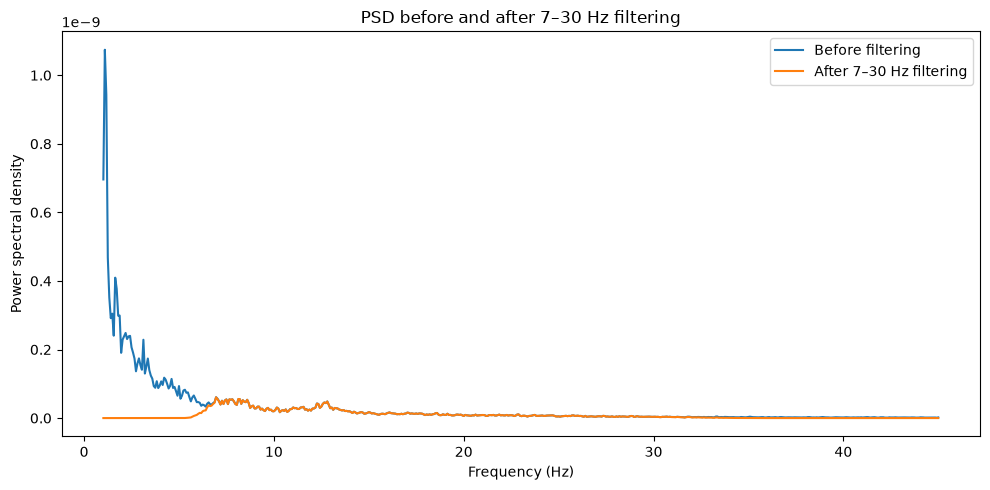

PosixPath('/Users/heihei/Desktop/neurosignallab/figures/week4_subject01_filter_psd_qc.png')

In [13]:
before_data, freqs = psd_before.get_data(
    return_freqs=True
)

after_data = psd_after.get_data()

before_mean = before_data.mean(axis=0)
after_mean = after_data.mean(axis=0)

plt.figure(figsize=(10, 5))

plt.plot(
    freqs,
    before_mean,
    label="Before filtering"
)

plt.plot(
    freqs,
    after_mean,
    label="After 7–30 Hz filtering"
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power spectral density")
plt.title("PSD before and after 7–30 Hz filtering")
plt.legend()
plt.tight_layout()

psd_path = (
    FIGURES_DIR
    / "week4_subject01_filter_psd_qc.png"
)

plt.savefig(
    psd_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

psd_path

### Summary of Quality control

Now the data has gone through four stages: 

- Raw data
- Standardized and montaged
- Concatentated with boundary annotations + referencing-projector
- Filtered to 7-30 Hz

## Metadata and event creation

### Create events from annotation

In [14]:
events, event_id = mne.events_from_annotations(raw)

motor_event_id = {
    "left": event_id["T1"],
    "right": event_id["T2"]
}

is_motor_event = np.isin(
    events[:, 2],
    list(motor_event_id.values())
)

motor_events = events[is_motor_event]

### Event extraction and define metadata

In [15]:
metadata_rows = []

for run, raw_run in zip(runs, raws):

    run_events, run_event_id = (
        mne.events_from_annotations(raw_run)
    )

    is_motor_event_run = (
        (run_events[:, 2] == run_event_id["T1"])
        |
        (run_events[:, 2] == run_event_id["T2"])
    )

    motor_events_run = run_events[
        is_motor_event_run
    ]

    for trial_in_run, event in enumerate(
        motor_events_run,
        start=1
    ):
        event_code = event[2]

        if event_code == run_event_id["T1"]:
            annotation = "T1"
            class_label = "left"
        else:
            annotation = "T2"
            class_label = "right"

        metadata_rows.append({
            "subject": subject,
            "run": run,
            "trial_in_run": trial_in_run,
            "annotation": annotation,
            "class_label": class_label, 
        })

metadata_df = pd.DataFrame(
    metadata_rows
)

metadata_df.head()

,subject,run,trial_in_run,annotation,class_label
0,1,4,1,T2,right
1,1,4,2,T1,left
2,1,4,3,T1,left
3,1,4,4,T2,right
4,1,4,5,T2,right


### Quality check metadata

In [16]:
print("Metadata rows:", len(metadata_df))

print("\nClass counts:")
print(metadata_df["class_label"].value_counts())

print("\nTrials by run and class:")
print(
    metadata_df
    .groupby(["run", "class_label"])
    .size()
)

metadata_df

Metadata rows: 45

Class counts:
class_label
left     23
right    22
Name: count, dtype: int64

Trials by run and class:
run  class_label
4    left           8
     right          7
8    left           8
     right          7
12   left           7
     right          8
dtype: int64


,subject,run,trial_in_run,annotation,class_label
0,1,4,1,T2,right
1,1,4,2,T1,left
2,1,4,3,T1,left
3,1,4,4,T2,right
4,1,4,5,T2,right
5,1,4,6,T1,left
6,1,4,7,T2,right
7,1,4,8,T1,left
8,1,4,9,T2,right
9,1,4,10,T1,left


### Create Epochs

In [17]:
epochs = mne.Epochs(
    raw,
    motor_events,
    event_id=motor_event_id,
    tmin=-1.0,
    tmax=4.0,
    baseline=None,
    preload=True,
    proj=True,
    metadata=metadata_df
)

### Check meta-data attached to epoch

In [18]:
epoch_data = epochs.get_data()

print("Epoch shape:", epoch_data.shape)
print("Metadata rows:", len(epochs.metadata))
print("Contains NaN:", np.isnan(epoch_data).any())
print("Contains infinity:", np.isinf(epoch_data).any())

Epoch shape: (45, 64, 801)
Metadata rows: 45
Contains NaN: False
Contains infinity: False


### Inspect epoch peak-to-peak amplitudes

In [19]:
ptp_per_channel = np.ptp(
    epoch_data,
    axis=2
)

ptp_max_per_epoch = ptp_per_channel.max(
    axis=1
)

ptp_max_microvolts = (
    ptp_max_per_epoch * 1e6
)

ptp_summary = pd.Series(
    ptp_max_microvolts
).describe()

ptp_summary

count     45.000000
mean     176.085423
std       38.843893
min      116.364294
25%      149.046761
50%      173.523997
75%      188.521345
max      293.956213
dtype: float64

### Create ML epoch-window

In [20]:
epochs_ml = epochs.copy().crop(
    tmin=1.0,
    tmax=4.0
)

X = epochs_ml.get_data()

label_to_y = {
    "left": 0,
    "right": 1
}

y = (
    epochs_ml.metadata["class_label"]
    .map(label_to_y)
    .to_numpy()
)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class counts:", np.unique(y, return_counts=True))

X shape: (45, 64, 481)
y shape: (45,)
Class counts: (array([0, 1]), array([23, 22]))


## Summary

This notebook established the preprocessing pipeline for motor-imagery EEG using Subject 1.

The final pipeline:
1. Loads runs 4, 8, and 12.
2. Standardizes channel names and applies the standard montage.
3. Concatenates runs and applies an average EEG reference.
4. Band-pass filters the signal from 7–30 Hz.
5. Selects T1/T2 left- and right-fist motor-imagery events.
6. Creates epochs from -1 to +4 s.
7. Retains +1 to +4 s as the machine-learning window.

Basic QC, PSD inspection, epoch dimensions, NaN/Inf checks, and peak-to-peak amplitudes were used to validate the pipeline before making it reusable.

The next step is to test whether the same preprocessing procedure works consistently across multiple subjects.